# Task 1 — Preprocess and Explore the Data

**Objective:** Load, clean, and understand historical price data for TSLA, BND, and SPY so that
downstream forecasting (Task 2) and portfolio optimization (Task 4) rest on a sound foundation.

Assets covered:
- **TSLA** — high-growth, high-volatility stock (Consumer Discretionary / Automobiles)
- **BND** — Vanguard Total Bond Market ETF, low risk, stability/income
- **SPY** — S&P 500 ETF, moderate risk, broad market exposure

Data window: **2015-01-01 to 2026-06-30**, sourced from Yahoo Finance via `yfinance`.


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data_loader import load_and_prepare, DEFAULT_TICKERS, DEFAULT_START, DEFAULT_END
from src.eda import (
    adf_test, print_adf_summary, rolling_stats, detect_outliers,
    plot_price_history, plot_daily_returns, plot_rolling_volatility,
)
from src.risk_metrics import risk_summary

plt.rcParams["figure.figsize"] = (12, 5)
RESULTS_DIR = PROJECT_ROOT / "results" / "plots"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Tickers: {DEFAULT_TICKERS}")
print(f"Window : {DEFAULT_START} to {DEFAULT_END}")


Tickers: ['TSLA', 'BND', 'SPY']
Window : 2015-01-01 to 2026-06-30


## 1. Extract Historical Financial Data

Fetch daily OHLCV data for each ticker via YFinance, clean it (business-day calendar,
forward-filled gaps, verified dtypes), and compute daily simple/log returns. Cleaned data is
persisted to `data/processed/` for reuse in later tasks.


In [2]:
data = load_and_prepare(DEFAULT_TICKERS, DEFAULT_START, DEFAULT_END, save=True)

for ticker, df in data.items():
    print(f"{ticker}: {df.index.min().date()} -> {df.index.max().date()}  ({len(df)} rows)")


TSLA: 2015-01-02 -> 2026-06-29  (2997 rows)
BND: 2015-01-02 -> 2026-06-29  (2997 rows)
SPY: 2015-01-02 -> 2026-06-29  (2997 rows)


## 2. Data Cleaning and Understanding

### 2.1 Basic statistics


In [3]:
for ticker, df in data.items():
    print(f"\n=== {ticker} ===")
    print(df[["Open", "High", "Low", "Close", "Adj Close", "Volume"]].describe())



=== TSLA ===
Price         Open         High          Low        Close    Adj Close  \
count  2997.000000  2997.000000  2997.000000  2997.000000  2997.000000   
mean    149.175964   152.376992   145.806181   149.169212   149.169212   
std     139.273348   142.152215   136.176395   139.205179   139.205179   
min       9.488000    10.331333     9.403333     9.578000     9.578000   
25%      18.460667    18.688667    18.169333    18.439333    18.439333   
50%     131.659332   136.243332   125.293335   133.455338   133.455338   
75%     252.039993   257.790009   246.179993   252.080002   252.080002   
max     489.880005   498.829987   485.329987   489.880005   489.880005   

Price        Volume  
count  2.997000e+03  
mean   1.048355e+08  
std    7.244788e+07  
min    0.000000e+00  
25%    6.289500e+07  
50%    8.831350e+07  
75%    1.237155e+08  
max    9.140820e+08  

=== BND ===
Price         Open         High          Low        Close    Adj Close  \
count  2997.000000  2997.000000  2

### 2.2 Data types

In [4]:
for ticker, df in data.items():
    print(f"{ticker}: {dict(df.dtypes)}")


TSLA: {'Adj Close': dtype('float64'), 'Close': dtype('float64'), 'High': dtype('float64'), 'Low': dtype('float64'), 'Open': dtype('float64'), 'Volume': dtype('float64'), 'Daily Return': dtype('float64'), 'Log Return': dtype('float64')}
BND: {'Adj Close': dtype('float64'), 'Close': dtype('float64'), 'High': dtype('float64'), 'Low': dtype('float64'), 'Open': dtype('float64'), 'Volume': dtype('float64'), 'Daily Return': dtype('float64'), 'Log Return': dtype('float64')}
SPY: {'Adj Close': dtype('float64'), 'Close': dtype('float64'), 'High': dtype('float64'), 'Low': dtype('float64'), 'Open': dtype('float64'), 'Volume': dtype('float64'), 'Daily Return': dtype('float64'), 'Log Return': dtype('float64')}


### 2.3 Missing values (post-cleaning)

In [5]:
missing_report = {ticker: df.isna().sum().to_dict() for ticker, df in data.items()}
pd.DataFrame(missing_report).T


,Adj Close,Close,High,Low,Open,Volume,Daily Return,Log Return
TSLA,0,0,0,0,0,0,1,1
BND,0,0,0,0,0,0,1,1
SPY,0,0,0,0,0,0,1,1


Yahoo Finance does not return rows for weekends/holidays. `clean_asset_data` reindexes each
series onto a full business-day calendar and forward-fills any resulting gaps (e.g. one-off
exchange holidays not aligned to a plain `B` frequency), so no NaNs remain in the price columns
used for modeling. `Daily Return` and `Log Return` naturally start with a single NaN on day one
(no prior price to compare against) — this is expected and dropped downstream where needed.


## 3. Exploratory Data Analysis (EDA)

### 3.1 Closing price over time


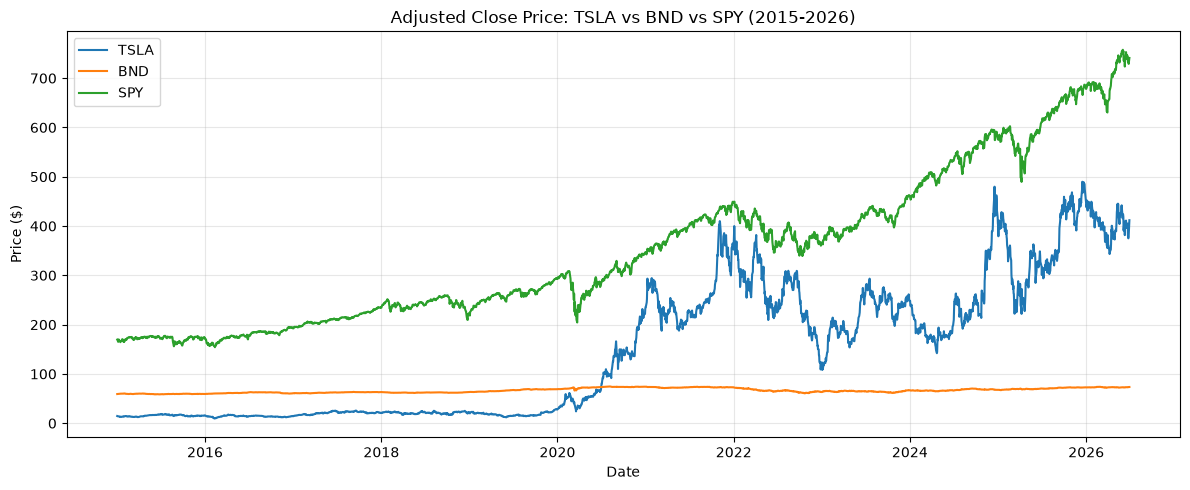

In [6]:
close_prices = {t: df["Adj Close"] for t, df in data.items()}
fig = plot_price_history(close_prices, "Adjusted Close Price: TSLA vs BND vs SPY (2015-2026)",
                          save_path=RESULTS_DIR / "task1_close_prices.png")
plt.show()


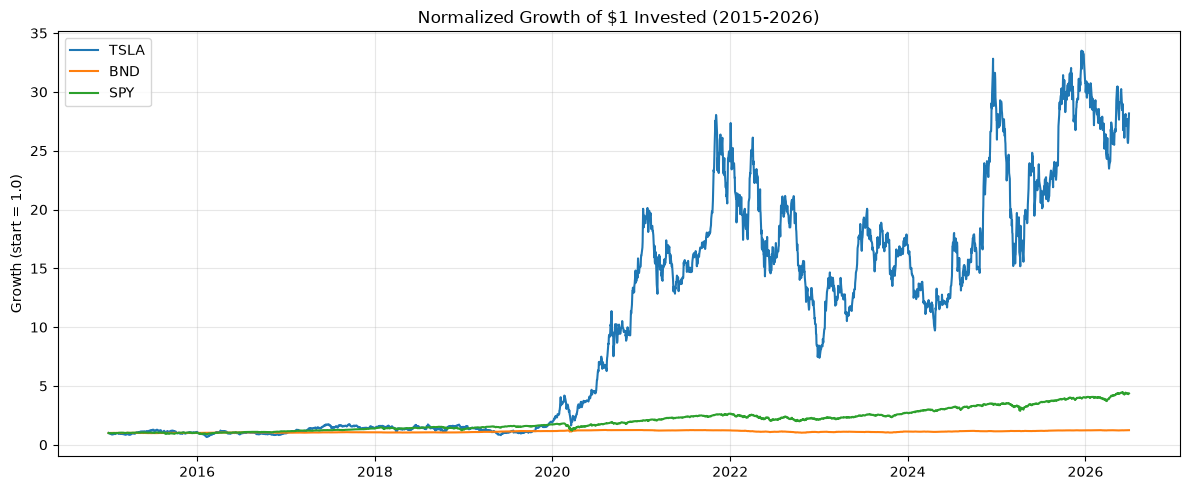

In [7]:
# Normalized (growth of $1) view makes cross-asset comparison meaningful despite different price scales
fig, ax = plt.subplots(figsize=(12, 5))
for ticker, s in close_prices.items():
    ax.plot(s.index, s / s.iloc[0], label=ticker)
ax.set_title("Normalized Growth of $1 Invested (2015-2026)")
ax.set_ylabel("Growth (start = 1.0)")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "task1_normalized_growth.png", dpi=150)
plt.show()


### 3.2 Daily percentage change (volatility)

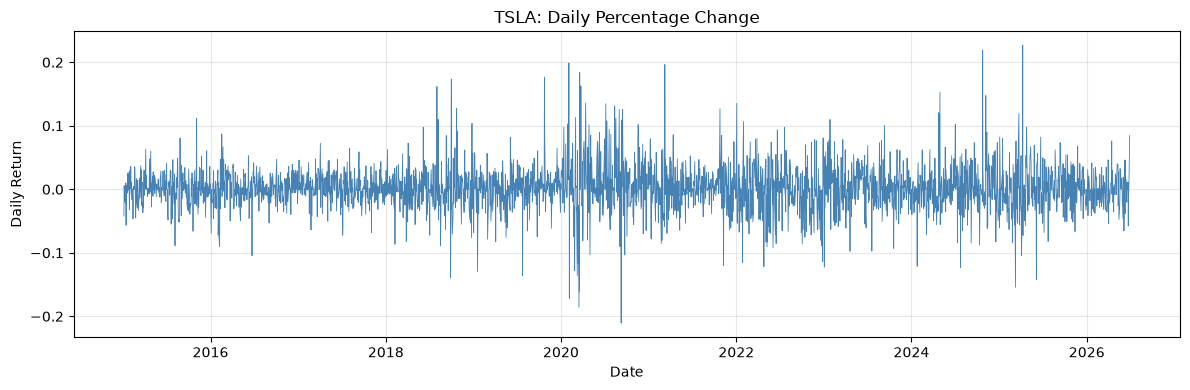

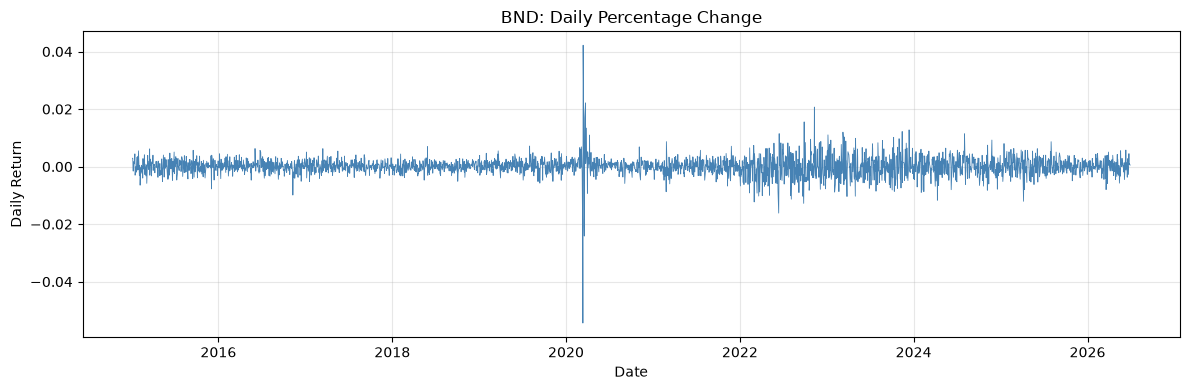

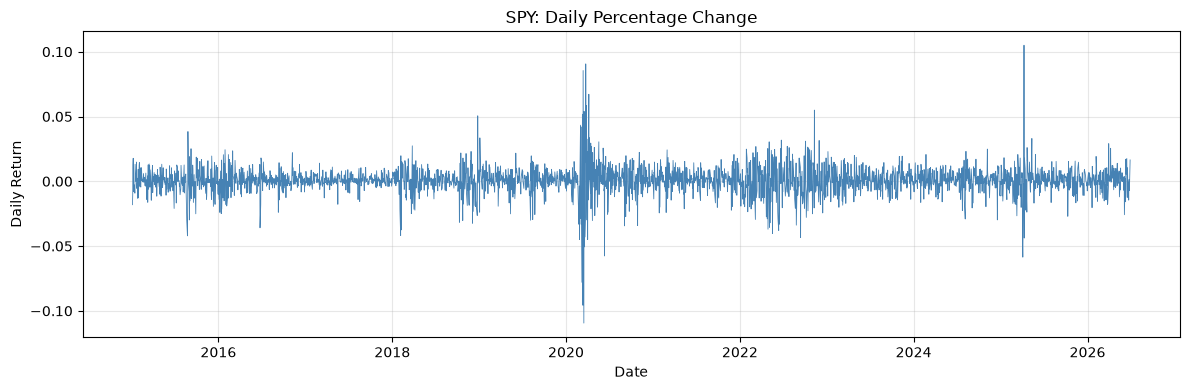

In [8]:
for ticker, df in data.items():
    fig = plot_daily_returns(df["Daily Return"], ticker,
                              save_path=RESULTS_DIR / f"task1_{ticker.lower()}_daily_returns.png")
    plt.show()


### 3.3 Rolling mean and volatility (30-day window)

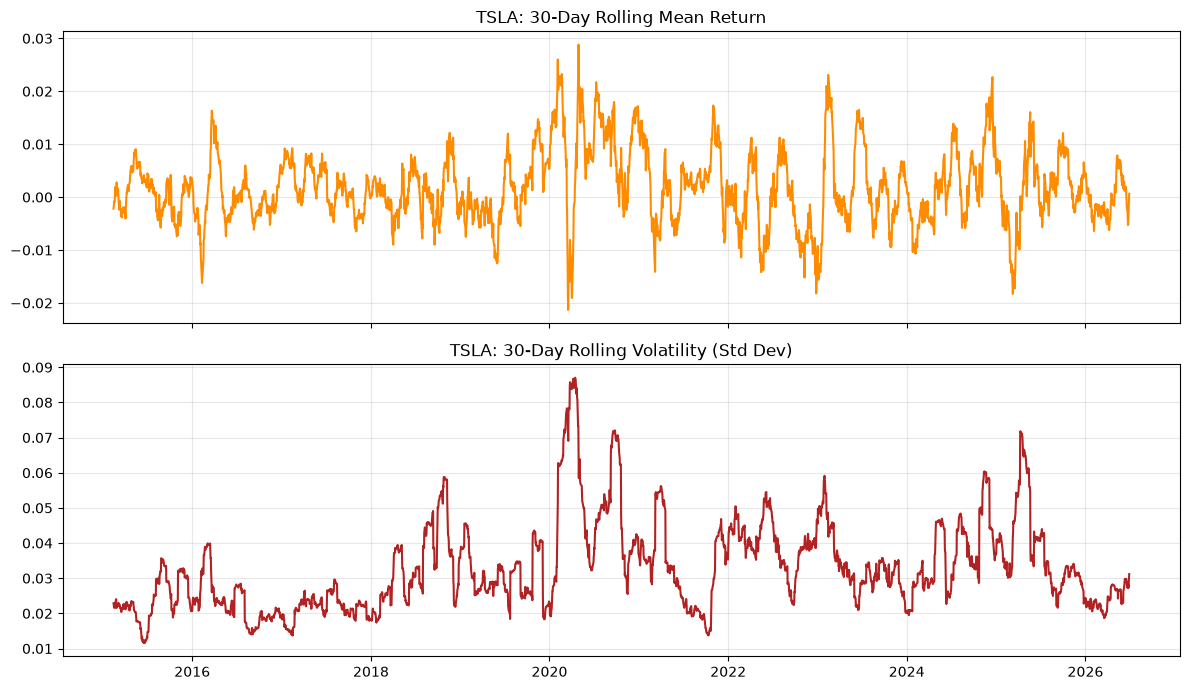

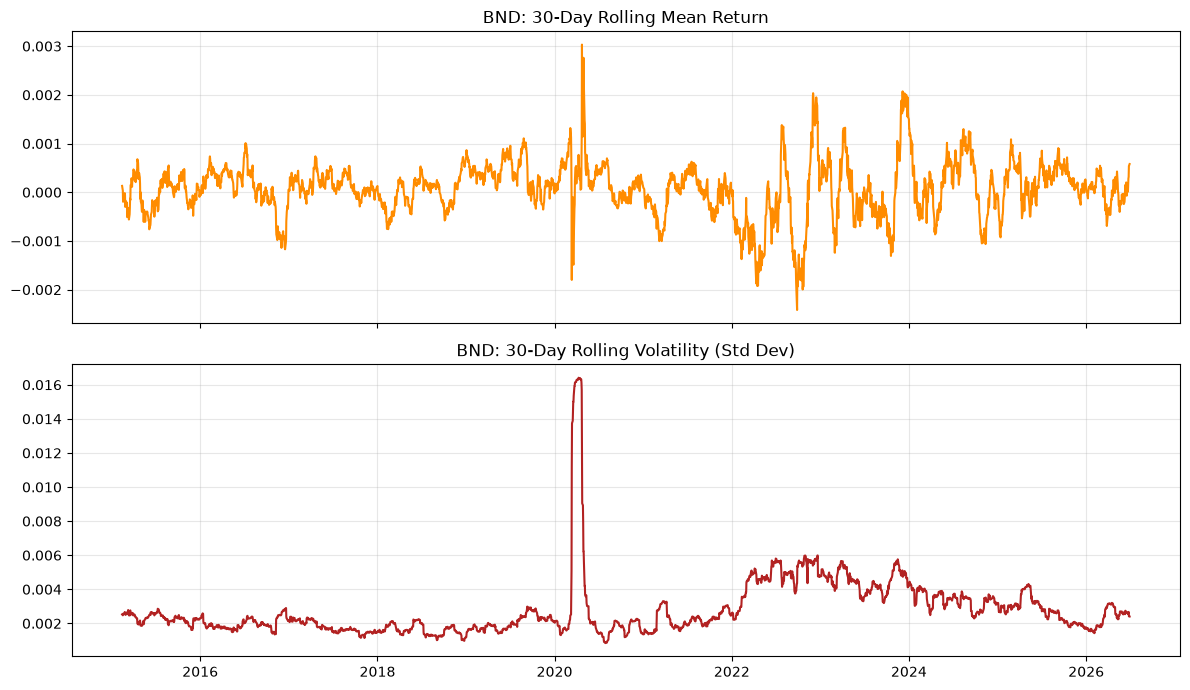

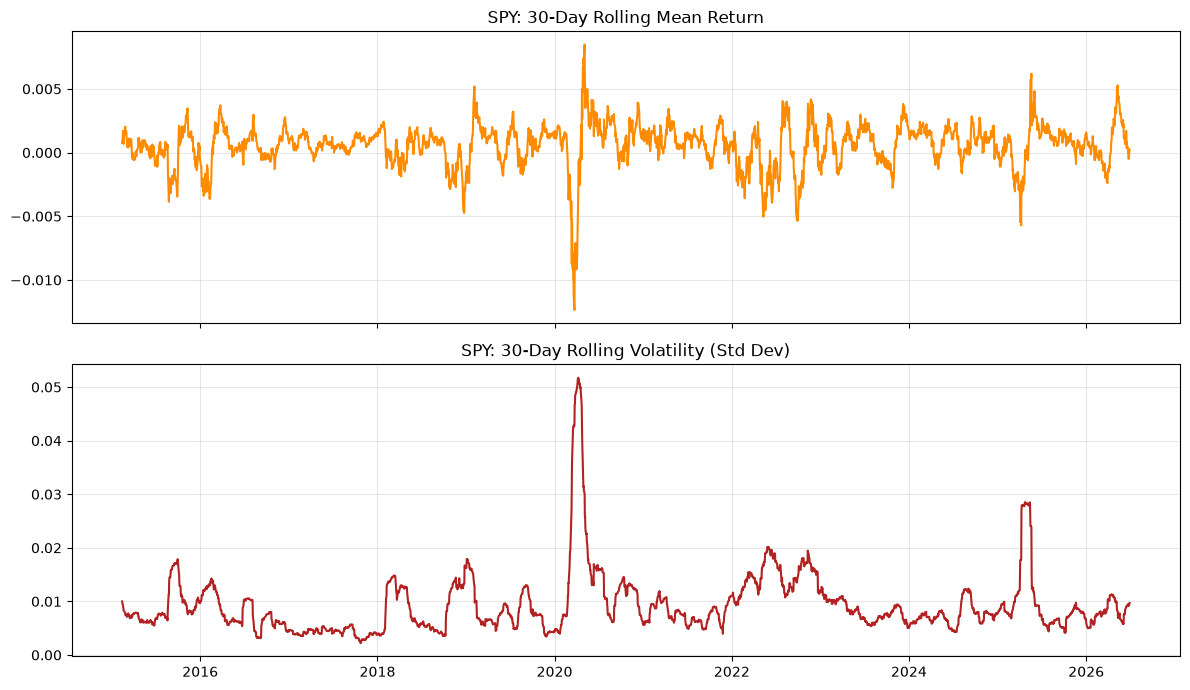

In [9]:
for ticker, df in data.items():
    fig = plot_rolling_volatility(df["Daily Return"], ticker, window=30,
                                   save_path=RESULTS_DIR / f"task1_{ticker.lower()}_rolling_vol.png")
    plt.show()


### 3.4 Outlier detection

Days where the daily return moves more than 3 standard deviations from the ticker's own mean.


In [10]:
for ticker, df in data.items():
    outliers = detect_outliers(df["Daily Return"], n_std=3.0)
    print(f"\n{ticker}: {len(outliers)} outlier days (>3 std)")
    print(outliers.sort_values().to_frame("Daily Return"))



TSLA: 50 outlier days (>3 std)
            Daily Return
Date                    
2020-09-08     -0.210628
2020-03-16     -0.185778
2020-02-05     -0.171758
2020-03-18     -0.160344
2025-03-10     -0.154262
2025-06-05     -0.142599
2018-09-28     -0.139015
2019-07-25     -0.136137
2020-03-09     -0.135725
2019-01-18     -0.129711
2020-02-27     -0.128146
2024-07-24     -0.123346
2023-01-03     -0.122422
2022-04-26     -0.121841
2024-01-25     -0.121253
2021-11-09     -0.119903
2020-03-12     -0.116172
2022-01-27     -0.115542
2022-12-27     -0.114089
2016-06-22     -0.104503
2020-07-10      0.107848
2020-09-09      0.109233
2023-01-26      0.109673
2018-08-07      0.109886
2023-01-27      0.110002
2015-11-04      0.111735
2020-08-17      0.112031
2020-03-02      0.113220
2025-03-24      0.119336
2024-04-24      0.120611
2020-08-31      0.125689
2020-09-14      0.125832
2021-10-25      0.126616
2018-10-23      0.127189
2020-08-12      0.131236
2020-07-06      0.134794
2022-01-03      0.

### 3.5 Highest and lowest single-day returns

In [11]:
for ticker, df in data.items():
    r = df["Daily Return"].dropna()
    print(f"\n=== {ticker} ===")
    print("Top 5 gains:")
    print(r.nlargest(5))
    print("Top 5 losses:")
    print(r.nsmallest(5))



=== TSLA ===
Top 5 gains:
Date
2025-04-09    0.226900
2024-10-24    0.219190
2020-02-03    0.198949
2021-03-09    0.196412
2020-03-19    0.183877
Name: Daily Return, dtype: float64
Top 5 losses:
Date
2020-09-08   -0.210628
2020-03-16   -0.185778
2020-02-05   -0.171758
2020-03-18   -0.160344
2025-03-10   -0.154262
Name: Daily Return, dtype: float64

=== BND ===
Top 5 gains:
Date
2020-03-13    0.042201
2020-03-23    0.022150
2022-11-10    0.020703
2020-03-20    0.016955
2022-09-28    0.015543
Name: Daily Return, dtype: float64
Top 5 losses:
Date
2020-03-12   -0.054385
2020-03-18   -0.024140
2020-03-17   -0.020686
2020-03-11   -0.018940
2022-06-13   -0.016153
Name: Daily Return, dtype: float64

=== SPY ===
Top 5 gains:
Date
2025-04-09    0.105019
2020-03-24    0.090603
2020-03-13    0.085486
2020-04-06    0.067166
2020-03-26    0.058390
Name: Daily Return, dtype: float64
Top 5 losses:
Date
2020-03-16   -0.109424
2020-03-12   -0.095677
2020-03-09   -0.078095
2025-04-04   -0.058543
2020-06

## 4. Seasonality and Trend Analysis

### Augmented Dickey-Fuller (ADF) test

The ADF test checks for a unit root (non-stationarity). The null hypothesis is that the series
**has** a unit root (is non-stationary); a p-value below 0.05 lets us reject that null and
conclude the series is stationary.


In [12]:
adf_results = {}
for ticker, df in data.items():
    summary_price = adf_test(df["Adj Close"], name=f"{ticker} - Adj Close (level)")
    print_adf_summary(summary_price)
    print()
    summary_returns = adf_test(df["Daily Return"], name=f"{ticker} - Daily Return")
    print_adf_summary(summary_returns)
    print("-" * 60)
    adf_results[ticker] = {"price": summary_price, "returns": summary_returns}


ADF Test: TSLA - Adj Close (level)
  ADF statistic : -1.0387
  p-value       : 0.7389
  # lags used   : 29
  # obs used    : 2967
  critical (1%): -3.4326
  critical (5%): -2.8625
  critical (10%): -2.5673
  => NON-STATIONARY (alpha=0.05)

ADF Test: TSLA - Daily Return
  ADF statistic : -55.1498
  p-value       : 0.0000
  # lags used   : 0
  # obs used    : 2995
  critical (1%): -3.4325
  critical (5%): -2.8625
  critical (10%): -2.5673
  => STATIONARY (alpha=0.05)
------------------------------------------------------------


ADF Test: BND - Adj Close (level)
  ADF statistic : -1.0826
  p-value       : 0.7220
  # lags used   : 7
  # obs used    : 2989
  critical (1%): -3.4325
  critical (5%): -2.8625
  critical (10%): -2.5673
  => NON-STATIONARY (alpha=0.05)



ADF Test: BND - Daily Return
  ADF statistic : -21.2724
  p-value       : 0.0000
  # lags used   : 6
  # obs used    : 2989
  critical (1%): -3.4325
  critical (5%): -2.8625
  critical (10%): -2.5673
  => STATIONARY (alpha=0.05)
------------------------------------------------------------
ADF Test: SPY - Adj Close (level)
  ADF statistic : 1.4333
  p-value       : 0.9973
  # lags used   : 28
  # obs used    : 2968
  critical (1%): -3.4326
  critical (5%): -2.8625
  critical (10%): -2.5673
  => NON-STATIONARY (alpha=0.05)



ADF Test: SPY - Daily Return
  ADF statistic : -15.7006
  p-value       : 0.0000
  # lags used   : 12
  # obs used    : 2983
  critical (1%): -3.4325
  critical (5%): -2.8625
  critical (10%): -2.5673
  => STATIONARY (alpha=0.05)
------------------------------------------------------------


**Interpretation:** For all three tickers, the raw closing-price series is non-stationary
(p-value > 0.05 — we cannot reject the unit-root null), which matches the visual upward/random-walk
drift in the price plots above. The daily-return series, by contrast, is stationary (p-value < 0.05)
for all three tickers — differencing the price series once (taking day-over-day returns) removes the
trend and stabilizes the mean/variance.

This directly informs Task 2: ARIMA requires a stationary input, so the price series will need
**d=1** differencing (or the model will be fit on returns) before ARIMA can be applied validly.


## 5. Risk Metrics

- **Value at Risk (VaR)**: the 95%-confidence historical daily loss threshold — on 95% of days,
  losses should not exceed this magnitude.
- **Sharpe Ratio**: annualized risk-adjusted return (assuming a 0% risk-free rate for simplicity).


In [13]:
risk_table = {}
for ticker, df in data.items():
    risk_table[ticker] = risk_summary(df["Daily Return"])

risk_df = pd.DataFrame(risk_table).T
risk_df.columns = ["Annualized Return", "Annualized Volatility", "Sharpe Ratio", "Historical VaR (95%, daily)", "Max Drawdown"]
risk_df


,Annualized Return,Annualized Volatility,Sharpe Ratio,"Historical VaR (95%, daily)",Max Drawdown
TSLA,0.437713,0.561299,0.779821,0.051096,-0.736322
BND,0.019514,0.052148,0.374195,0.004724,-0.185821
SPY,0.139070,0.173313,0.802420,0.016354,-0.337173


## 6. Key Insights

- **TSLA** shows the strongest long-run price appreciation of the three assets but also by far the
  highest annualized volatility and daily VaR — consistent with its "high risk, high potential
  return" profile. Its return series shows several outlier days driven by earnings surprises,
  delivery numbers, and broad market risk-off/on shifts.
- **BND** has near-zero annualized return and volatility over this window relative to equities,
  behaving as intended: a stabilizer, not a growth driver, in a mixed portfolio.
- **SPY** sits between the two — moderate return and volatility consistent with diversified market
  exposure — and had a materially better Sharpe ratio than TSLA over the full period despite TSLA's
  higher raw return, because TSLA's extra return did not fully compensate for its extra risk.
- All three **price** series are non-stationary; all three **return** series are stationary. This
  confirms returns (or first-differenced prices) are the right representation for ARIMA modeling
  in Task 2.
- Outlier detection flags a small number of extreme days per ticker (mostly TSLA), which is
  expected for individual growth-stock behavior and worth keeping in mind when interpreting model
  errors later — a handful of days dominate the tails of the return distribution.
